In [1]:
import polars as pl
import numpy as np
from util import plot_distribution_grid

In [2]:
#Load data

trips = pl.read_csv("../Data/trips.txt")

# Match join key types.
trips = trips.with_columns(
    pl.col("trip_id").cast(pl.Utf8),
    pl.col("route_id").cast(pl.Utf8),
)

routes = pl.read_csv("../Data/routes.txt")
routes = routes.with_columns(pl.col("route_id").cast(pl.Utf8))

updates = pl.read_parquet("../Data/final_trip_updates.parquet")

df = (
    updates
    .drop("route_id")
    .join(trips.select(["trip_id", "route_id"]), on="trip_id", how="left")
    .join(routes, on="route_id", how="left")
)

df.head()


provider,service_date,entity_id,vehicle_id,trip_id,stop_id,current_stop_sequence,timestamp,source,timestamp_utc,trip_start_date,trip_start_time,trip_schedule_relationship,trip_direction_id,stop_time_update_schedule_relationship,arrival_time,arrival_delay,arrival_time_utc,departure_time,departure_delay,departure_time_utc,stop_time_uncertainty,route_id,agency_id,route_short_name,route_long_name,route_type,route_desc
str,str,str,str,str,str,i64,i64,str,"datetime[μs, UTC]",str,str,i64,i64,i64,i64,i64,"datetime[μs, UTC]",i64,i64,"datetime[μs, UTC]",i64,str,i64,str,str,i64,str
"""otraf""","""2026-03-25""","""55700501354264604""","""9031005920505667""","""55700000081154342""","""9022005001445001""",9,1774434860,"""otraf:TripUpdates:2026-03-25:1…",2026-03-25 10:34:20 UTC,"""20260325""",null,0,null,null,1774434281,208,2026-03-25 10:24:41 UTC,1774434281,208,2026-03-25 10:24:41 UTC,0,"""9011005021600000""",55700000000001407,"""16""",null,700,null
"""otraf""","""2026-03-25""","""55700501338946756""","""9031005920804453""","""55700000081915075""","""9022005002977002""",10,1774456108,"""otraf:TripUpdates:2026-03-25:1…",2026-03-25 16:28:28 UTC,"""20260325""",null,0,null,null,1774455899,-48,2026-03-25 16:24:59 UTC,1774455899,-48,2026-03-25 16:24:59 UTC,0,"""9011005057100000""",55700000000001407,"""571""",null,700,null
"""otraf""","""2026-03-25""","""55700501353130488""","""9031005920505667""","""55700000074062872""","""9022005000417002""",3,1774456560,"""otraf:TripUpdates:2026-03-25:1…",2026-03-25 16:36:00 UTC,"""20260325""",null,0,null,null,1774455987,185,2026-03-25 16:26:27 UTC,1774455987,185,2026-03-25 16:26:27 UTC,0,"""9011005021200000""",55700000000001407,"""12""",null,700,null
"""otraf""","""2026-03-25""","""55700501368800571""","""9031005900306728""","""55700000081790239""","""9022005001365002""",3,1774449046,"""otraf:TripUpdates:2026-03-25:1…",2026-03-25 14:30:46 UTC,"""20260325""",null,0,null,null,1774448476,14,2026-03-25 14:21:16 UTC,1774448476,14,2026-03-25 14:21:16 UTC,0,"""9011005011000000""",55700000000001407,"""10""",null,700,null
"""otraf""","""2026-03-25""","""55700501373595814""","""9031005920703872""","""55700000082915796""","""9022005000038002""",9,1774466509,"""otraf:TripUpdates:2026-03-25:2…",2026-03-25 19:21:49 UTC,"""20260325""",null,0,null,null,1774465926,6,2026-03-25 19:12:06 UTC,1774465926,6,2026-03-25 19:12:06 UTC,0,"""9011005004000000""",55700000000001407,"""40""",null,700,null


In [3]:
# Find groups with the most observations and their average arrival delay
most_observed_trip_stop = (
    df.group_by(["route_id", "route_short_name", "stop_id"])
    .agg(
        pl.len().alias("observation_count"),
        pl.col("arrival_delay").mean().alias("avg_arrival_delay"),
    )
    .filter(pl.col("avg_arrival_delay") > 0)
    .sort("observation_count", descending=True)
    .head(100)
)

most_observed_trip_stop

route_id,route_short_name,stop_id,observation_count,avg_arrival_delay
str,str,str,u32,f64
"""9011005011100000""","""11""","""9022005001088001""",119,17.87395
"""9011005011100000""","""11""","""9022005001087001""",119,19.07563
"""9011005011100000""","""11""","""9022005001085001""",119,30.386555
"""9011005000300000""","""3""","""9022005000008016""",101,84.584158
"""9011005000200000""","""2""","""9022005001012017""",101,180.732673
…,…,…,…,…
"""9011005020100000""","""1""","""9022005001222001""",86,140.406977
"""9011005020100000""","""1""","""9022005001230001""",86,80.034884
"""9011005020100000""","""1""","""9022005000046003""",86,79.162791


* Medelvärde: 30.387, Median: 19.000
* Standardavvikelse: 56.387


### Arrival delay distribution | route_id=9011005011100000, stop_id=9022005001085001

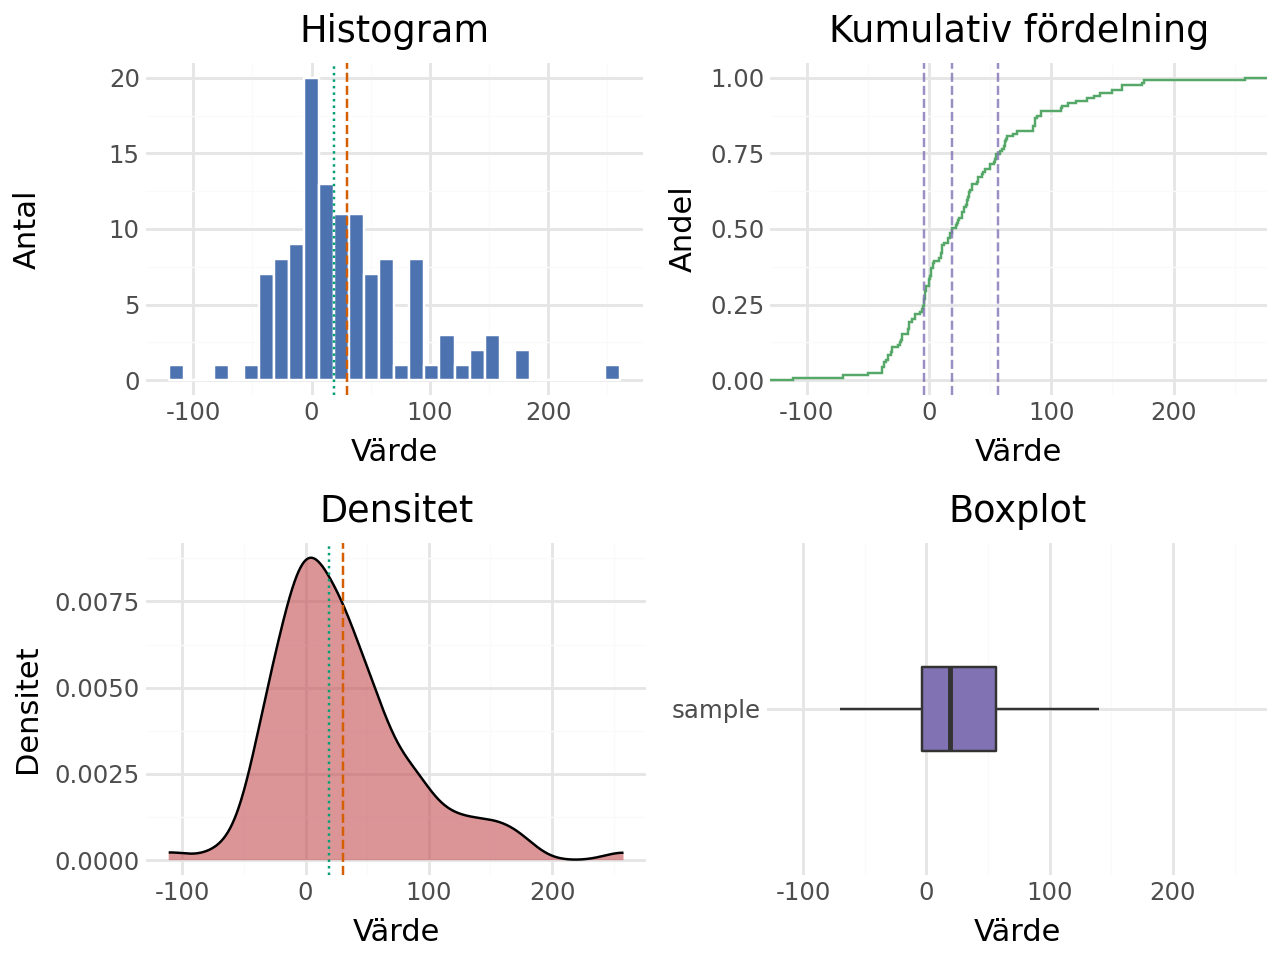

In [4]:
# Plot distribution of arrival_delay for a chosen route_id and stop_id (ggplot2-like style)


route_id_value = "9011005011100000" #Linje 1
stop_id_value = "9022005001085001" #Urbergsgatan


plot_df = (
    df.filter(
        (pl.col("route_id") == route_id_value)
        & (pl.col("stop_id") == stop_id_value)
        & pl.col("arrival_delay").is_not_null()
    )
    .select("arrival_delay")
    .to_pandas()
)

plot_distribution_grid(
    title=f"Arrival delay distribution | route_id={route_id_value}, stop_id={stop_id_value}",
    data_sample=plot_df["arrival_delay"]
)


In [ ]:
# Plot distribution of arrival_delay for a chosen route_id and stop_id (ggplot2-like style)


route_id_value = "9011005011100000" #Linje 1
stop_id_value = "9022005001085001" #Urbergsgatan


plot_df = (
    df.filter(
        (pl.col("route_id") == route_id_value)
        & (pl.col("stop_id") == stop_id_value)
        & pl.col("arrival_delay").is_not_null()
    )
    .select("arrival_delay")
    .to_pandas()
)

plot_distribution_grid(
    title=f"Arrival delay distribution | route_id={route_id_value}, stop_id={stop_id_value}",
    data_sample=plot_df["arrival_delay"]
)


Normalfordelad data -> medelvarde: 0.941, standardavvikelse: 3.000
* Medelvärde: 0.941, Median: 0.997
* Standardavvikelse: 3.000


### Normalfördelad data

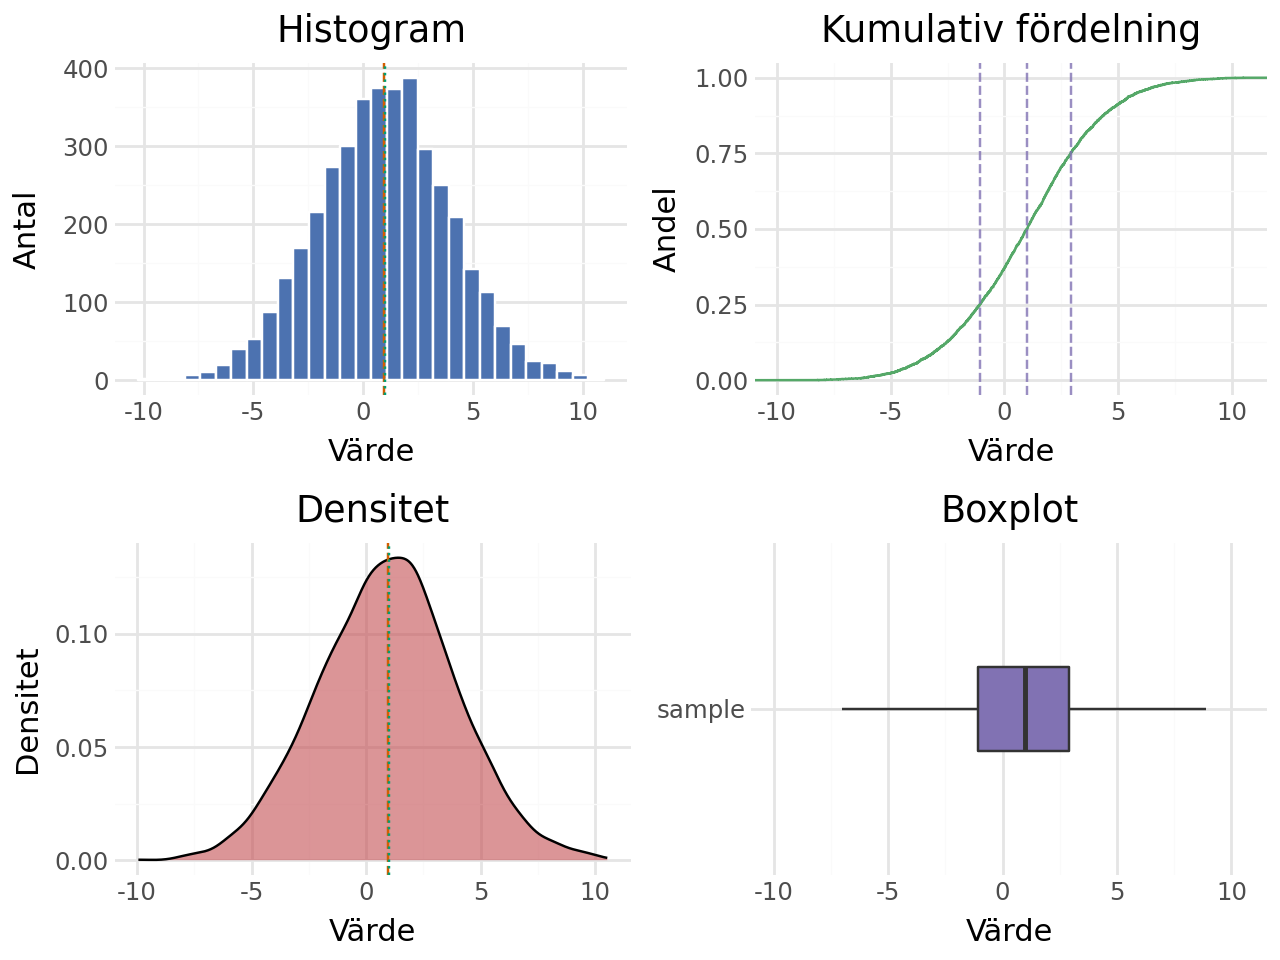

In [5]:
# Exempel 1: Normalfordelad data med medelvarde 1
rng = np.random.default_rng(42)
normal_data = rng.normal(loc=1, scale=3, size=4000)
print(f"Normalfordelad data -> medelvarde: {normal_data.mean():.3f}, standardavvikelse: {normal_data.std(ddof=1):.3f}")
plot_distribution_grid("Normalfördelad data", normal_data)

Lognormalfordelad data -> medelvarde: 0.995, standardavvikelse: 0.414
* Medelvärde: 0.995, Median: 0.913
* Standardavvikelse: 0.414


### Lognormalfordelad data

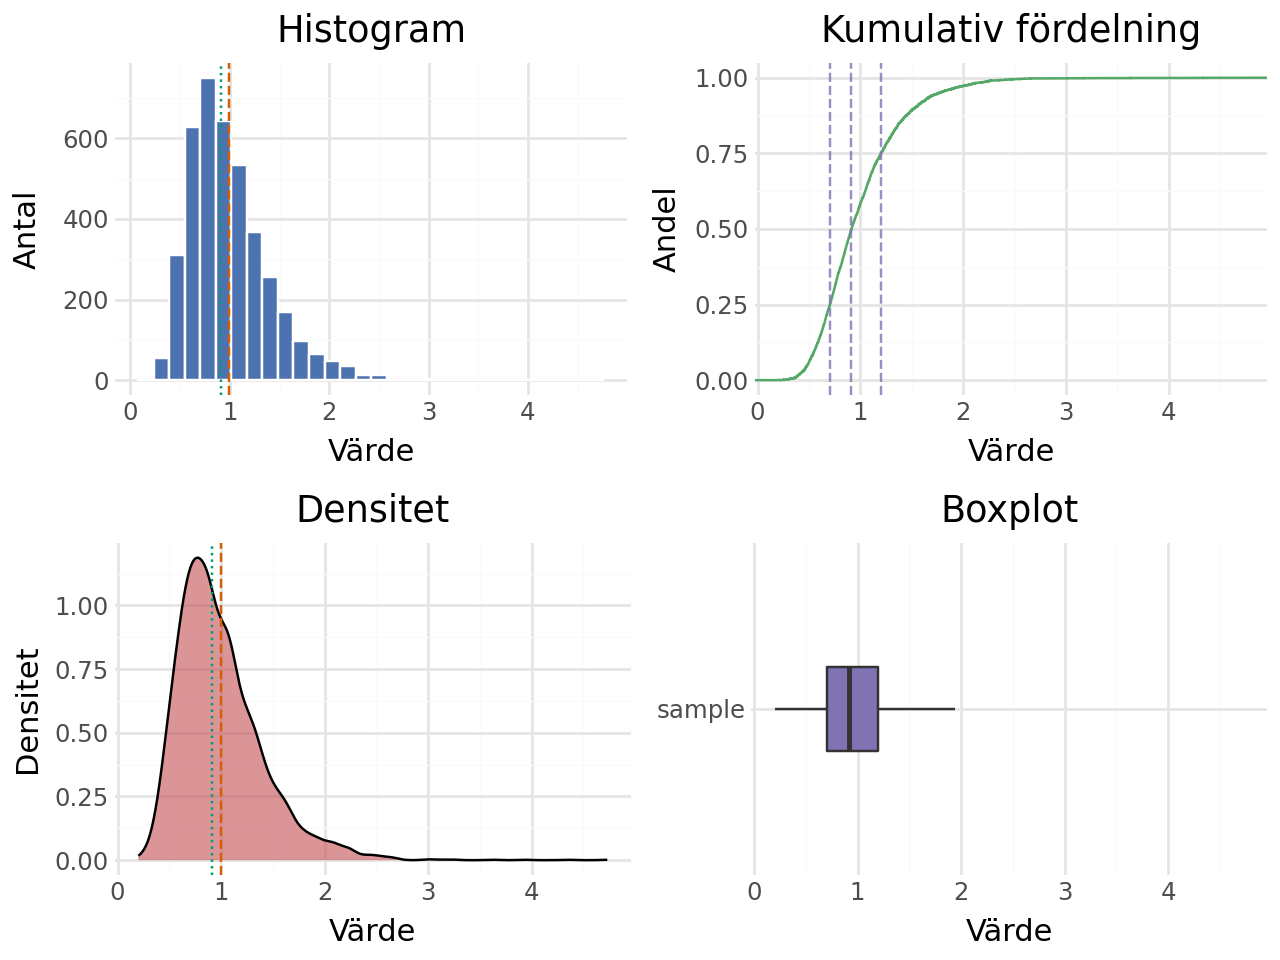

In [16]:
# Exempel 2: Lognormalfordelad data (hogerskev) med medelvarde 1 och mindre spridning
sigma = 0.4
mu = -(sigma**2) / 2
lognormal_data = rng.lognormal(mean=mu, sigma=sigma, size=4000)
print(f"Lognormalfordelad data -> medelvarde: {lognormal_data.mean():.3f}, standardavvikelse: {lognormal_data.std(ddof=1):.3f}")
plot_distribution_grid("Lognormalfordelad data", lognormal_data)

Likformigt fordelad data -> medelvarde: 0.999, standardavvikelse: 0.576
* Medelvärde: 0.999, Median: 1.010
* Standardavvikelse: 0.576


### Likformigt fordelad data

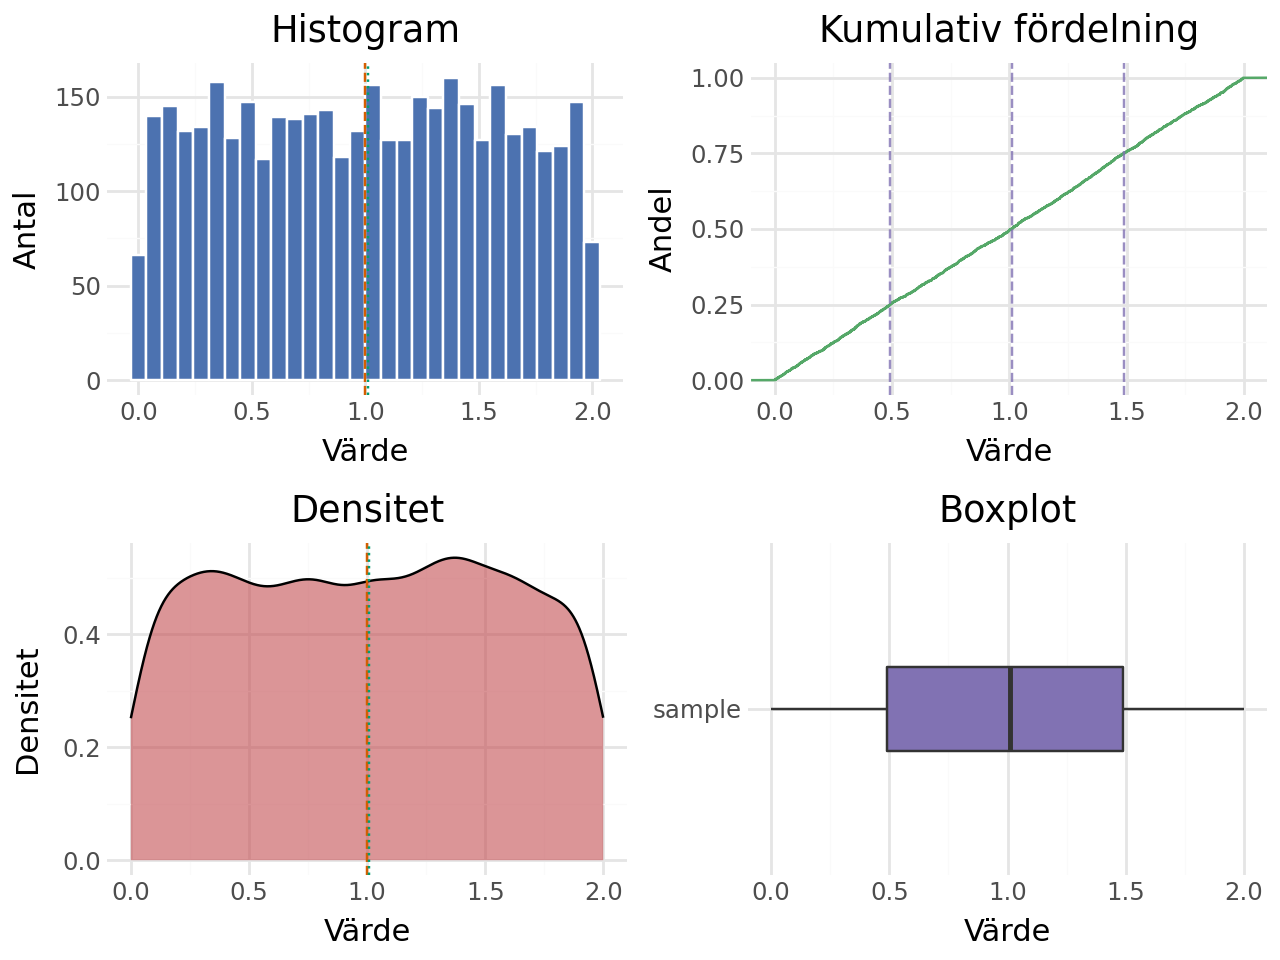

In [7]:
# Exempel 3: Likformigt fordelad data med medelvarde 1
uniform_data = rng.uniform(0, 2, size=4000)
print(f"Likformigt fordelad data -> medelvarde: {uniform_data.mean():.3f}, standardavvikelse: {uniform_data.std(ddof=1):.3f}")
plot_distribution_grid("Likformigt fordelad data", uniform_data)

1,2,3,999
* Medelvärde: 34.000, Median: 2.000
* Standardavvikelse: 56.294


### 1,2,3,999

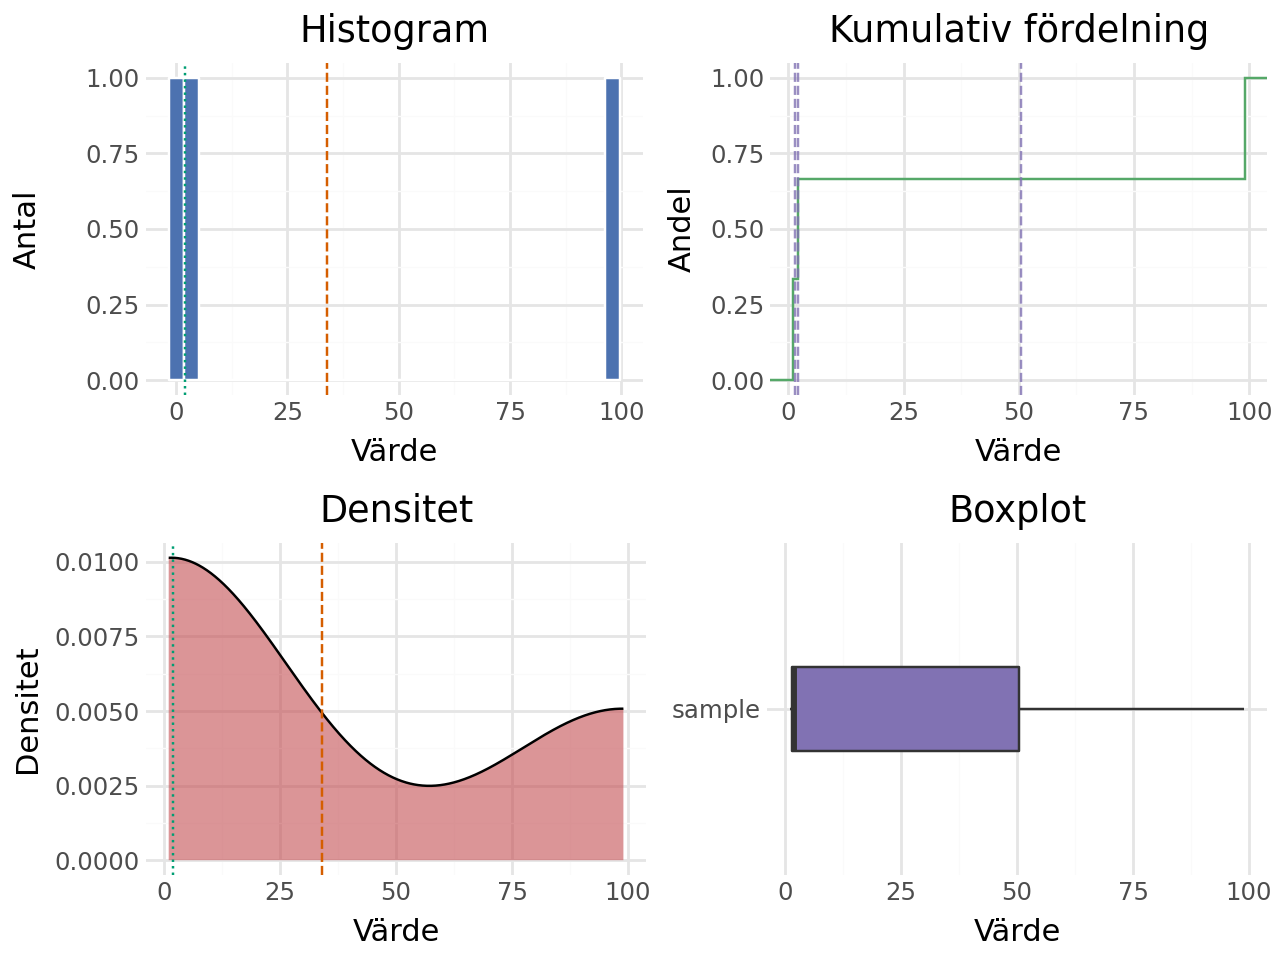

In [24]:
# Exempel 3: Likformigt fordelad data med medelvarde 1
sample = [1,2,99]
print(f"1,2,3,999")
plot_distribution_grid("1,2,3,999", sample)

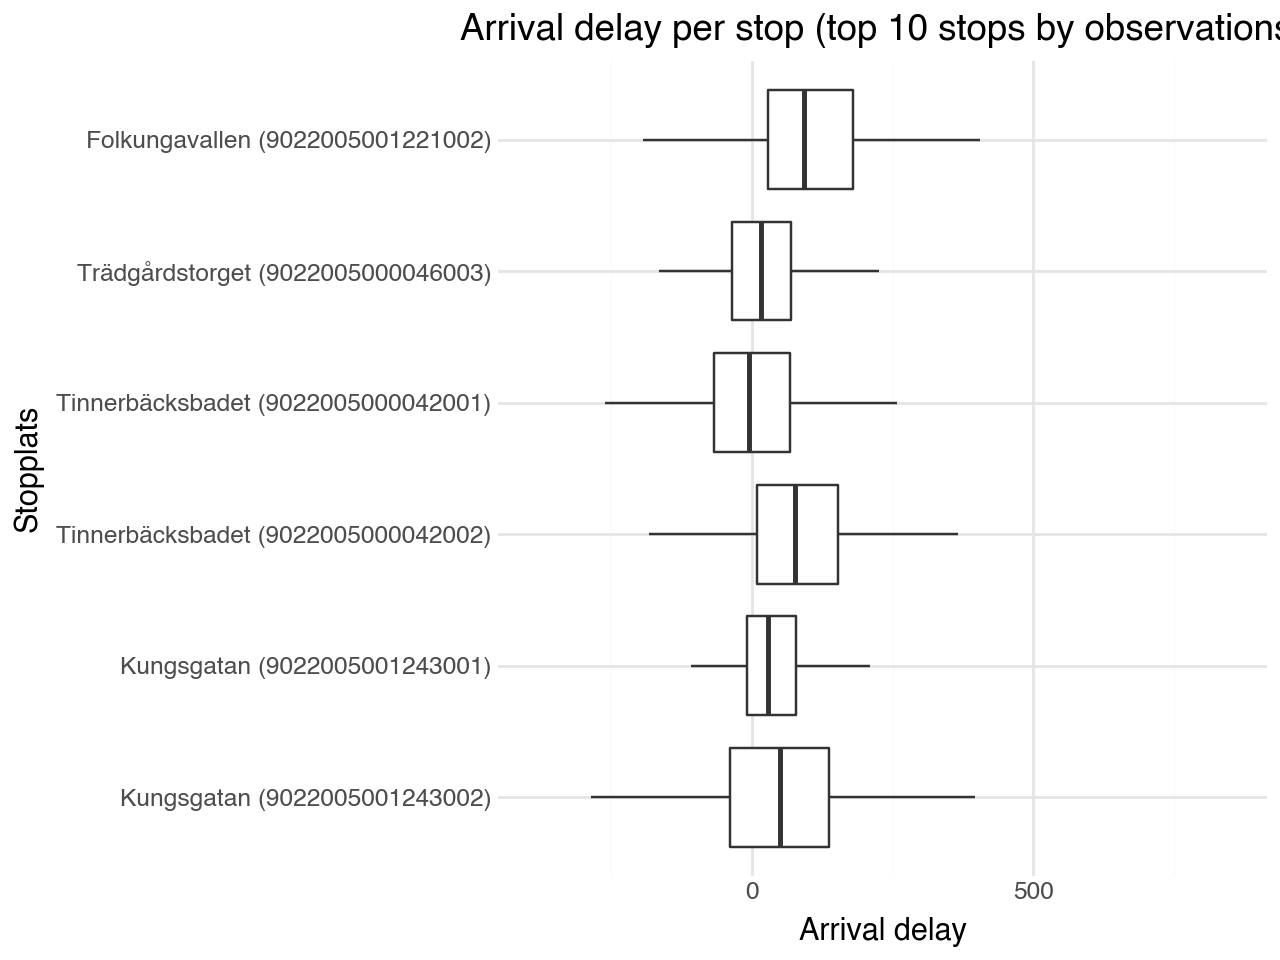

In [38]:
# Top 10 stops by observations (fixed labels to avoid duplicate categories)
from plotnine import aes, coord_flip, geom_boxplot, ggplot, labs, theme_minimal
stops = pl.read_csv("../Data/stops.txt").select(["stop_id", "stop_name"])
stops = stops.with_columns(pl.col("stop_id").cast(pl.Utf8))
top_10_stops = (
    df.group_by("stop_id")
    .agg(pl.len().alias("observation_count"))
    .sort("observation_count", descending=True)
    .head(6)
)
plot_df = (
    df.join(top_10_stops.select("stop_id"), on="stop_id", how="inner")
    .join(stops, on="stop_id", how="left")
    .filter(pl.col("arrival_delay").is_not_null())
    .select(["stop_id", "stop_name", "arrival_delay"])
    .to_pandas()
)

# Use unique labels (name + stop_id) so category ordering always works.
plot_df["stop_label"] = plot_df["stop_name"].fillna(plot_df["stop_id"])
plot_df["stop_label"] = (
    plot_df["stop_label"].astype(str) + " (" + plot_df["stop_id"].astype(str) + ")"
)
stop_order = (
    top_10_stops.join(stops, on="stop_id", how="left")
    .with_columns(
        pl.when(pl.col("stop_name").is_null())
        .then(pl.col("stop_id"))
        .otherwise(pl.col("stop_name") + " (" + pl.col("stop_id") + ")")
        .alias("stop_label")
    )
    .get_column("stop_label")
    .to_list()
)
plot_df["stop_label"] = plot_df["stop_label"].astype("category").cat.set_categories(
    stop_order, ordered=True
)
(
    ggplot(plot_df, aes(x="stop_label", y="arrival_delay"))
    + geom_boxplot(outlier_alpha=0.0)
    + coord_flip()
    + labs(
        title="Arrival delay per stop (top 10 stops by observations)",
        x="Stopplats",
        y="Arrival delay",
    )
    + theme_minimal()
)


/Users/nilbr50/Documents/GitHub/dataanalys-for-kollektivtrafik/.venv/lib/python3.14/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_boxplot : Removed 47 rows containing non-finite values.


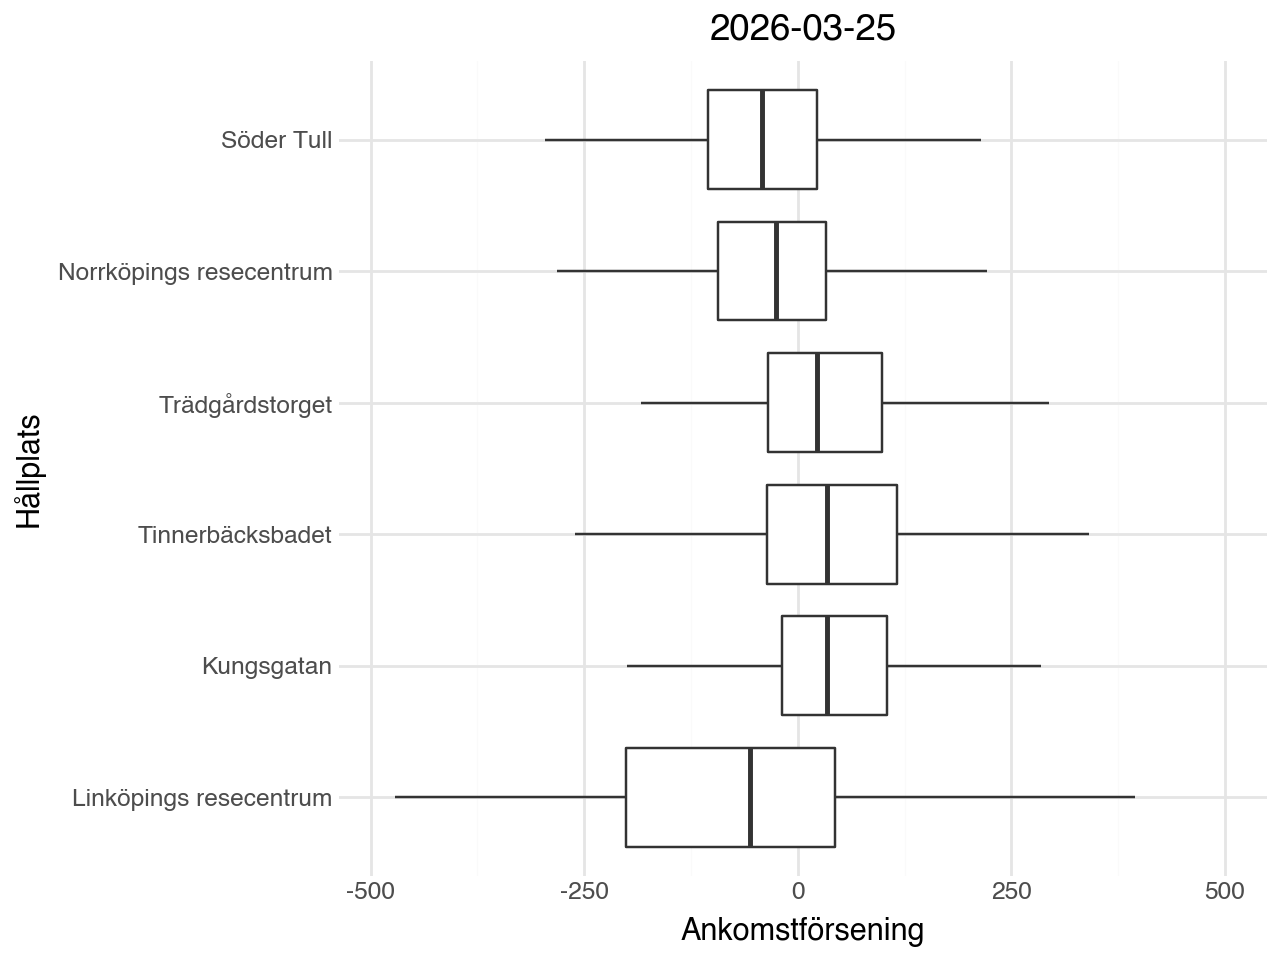

In [44]:
# Top 10 stops by observations: join stop_name first, then group by stop_name
from plotnine import (
    aes,
    coord_flip,
    geom_boxplot,
    ggplot,
    labs,
    scale_y_continuous,
    theme_minimal,
)

stops = pl.read_csv("../Data/stops.txt").select(["stop_id", "stop_name"])
stops = stops.with_columns(pl.col("stop_id").cast(pl.Utf8))

df_with_stops = (
    df.join(stops, on="stop_id", how="left")
    .with_columns(
        pl.when(pl.col("stop_name").is_null())
        .then(pl.col("stop_id"))
        .otherwise(pl.col("stop_name"))
        .alias("stop_name")
    )
)

top_6_stop_names = (
    df_with_stops.group_by("stop_name")
    .agg(pl.len().alias("observation_count"))
    .sort("observation_count", descending=True)
    .head(6)
)

plot_df = (
    df_with_stops.join(top_6_stop_names.select("stop_name"), on="stop_name", how="inner")
    .filter(pl.col("arrival_delay").is_not_null())
    .select(["stop_name", "arrival_delay"])
    .to_pandas()
)

stop_order = top_6_stop_names.get_column("stop_name").to_list()
plot_df["stop_name"] = plot_df["stop_name"].astype("category").cat.set_categories(
    stop_order, ordered=True
)

(
    ggplot(plot_df, aes(x="stop_name", y="arrival_delay"))
    + geom_boxplot(outlier_alpha=0.0)
    + scale_y_continuous(limits=(None, 500))
    + coord_flip()
    + labs(
        title="2026-03-25",
        x="Hållplats",
        y="Ankomstförsening",
    )
    + theme_minimal()
)

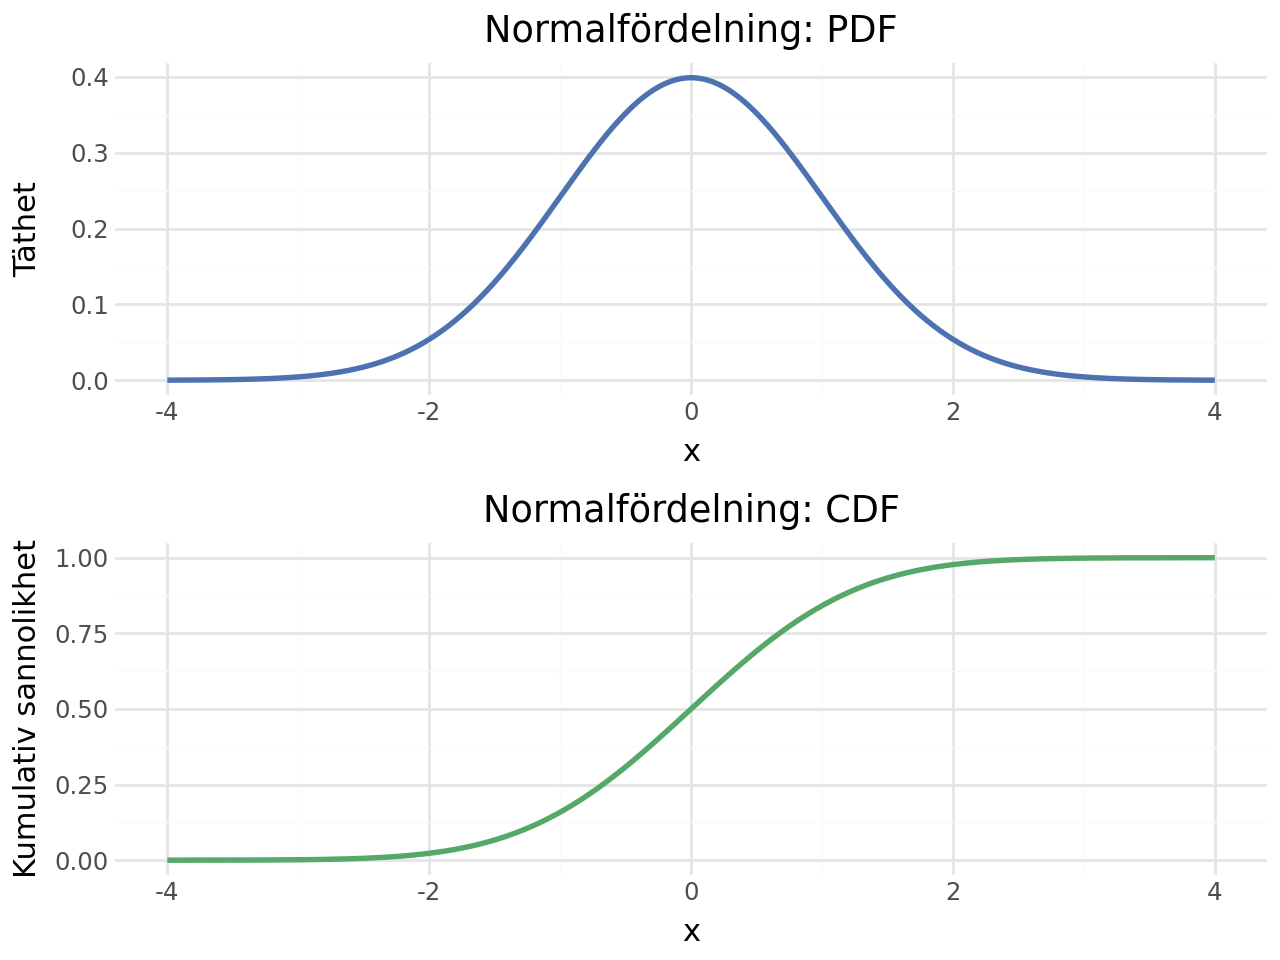

In [46]:
# Normal distribution: PDF (top) and CDF (bottom) using Polars
from math import erf, pi, sqrt
from plotnine import aes, geom_line, ggplot, labs, theme_minimal

x = np.linspace(-4, 4, 500)
pdf = (1 / np.sqrt(2 * pi)) * np.exp(-(x**2) / 2)
cdf = 0.5 * (1 + np.vectorize(erf)(x / sqrt(2)))

normal_df = pl.DataFrame({"x": x, "pdf": pdf, "cdf": cdf}).to_pandas()

pdf_plot = (
    ggplot(normal_df, aes(x="x", y="pdf"))
    + geom_line(color="#4C72B0", size=1.1)
    + labs(title="Normalfördelning: PDF", x="x", y="Täthet")
    + theme_minimal()
)

cdf_plot = (
    ggplot(normal_df, aes(x="x", y="cdf"))
    + geom_line(color="#55A868", size=1.1)
    + labs(title="Normalfördelning: CDF", x="x", y="Kumulativ sannolikhet")
    + theme_minimal()
)

(cdf_plot) / (pdf_plot)